<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #FFFFFF; max-width: 90%; overflow-x: auto; color: #000000;">

<img src="../resources/swdb_logo.jpg">


<h1 align="center">Workshop 2 Real Data: Visual Learning</h1>
<h3 align="center">Summer Workshop on the Dynamic Brain</h3>
<h4 align="center">Thursday, August 27th, 2026</h4>
<h4 align="center">Day 4</h4>

---

***Authors:** Nick Steinmetz, Carrie Stine*

---

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

## Applying the Analysis to Real Neural Recordings

In Workshop 2, we showed the pitfall in a simulation where we knew the ground truth.
Now we apply the same pipeline to a real session from the
**Visual Learning** dataset where the neurons *might* encode things, and we
need the controls to tell us what is real.

### The Visual Learning task

 The Visual Learning Dataset was generated using in vivo 2-photon calcium imaging (also called optical physiology, or “ophys”) to measure the activity of genetically identified neurons in the visual cortex of mice performing a go/no-go visual change detection task. 

 <img src="../resources/VisLearningOverview.png">

 This change detection task consists of a series of sequentially presented visual stimuli (4-12 presentations/stimulus), and throughout training they learn to report changes in stimulus identity by licking a spout to earn a reward. 
 
 Mice are trained on one set of images that becomes **familiar**, and then in a later session are presented with a new set of **novel** images that they haven't seen before. 


 An extension of the Visual Behavior dataset that you can learn about in the [Databook](https://allenswdb.github.io/physiology/ophys/visual-behavior/VB-Ophys.html), the Visual *Learning* dataset adds 2 key features:
 1. Longitudinal imaging **throughout task learning**
 2. Post-hoc measurement of gene expression using spatial transcriptomics to **group the recorded cells into different inhibitory subclasses** 


<img src="../resources/VisLearning-mFISH.png">

---

### What questions we could investigate in this dataset?
 1. What features do inhibitory subclasses (Pvalb, Sst, Vip, Lamp5) encode during behavior?
 2. How do novelty and behavioral state influence inhibitory interactions?
 3. How do inhibitory subclass interactions evolve during learning?


</div>


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

## What we will test in this example

1. **Test 1 (pupil analog):** Are neurons correlated with running speed? Like pupil size, running speed can also have slow structure. 
2. **Open Ended exercises**


</div>


In [1]:
import sys
import os
from pathlib import Path

if '__vsc_ipynb_file__' in dir():
    nb_dir = Path(__vsc_ipynb_file__).parent
    os.chdir(nb_dir)
    sys.path.append(str(nb_dir.parent))          # for workshop2_utils
else:
    sys.path.append("/code/Workshop-2_NonsenseCorrelations")

import importlib
import workshop2_utils
importlib.reload(workshop2_utils)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pynwb
from scipy import stats
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import KFold
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='hdmf_zarr')
warnings.filterwarnings("ignore", module="hdmf")

plt.rcParams['font.family']       = 'sans-serif'
plt.rcParams['font.sans-serif']   = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['pdf.fonttype']      = 42
plt.rcParams['ps.fonttype']       = 42

data_dir = '/data'

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

<h1>Part 1: Load the dataset and find the pieces you need</h1>

Same access pattern as earlier this week: find your dataset's mount under <code>/data</code>, locate a
session's NWB file, then dot and bracket notation into the containers.

</div>

In [2]:
# read the Visual Learning dataset's metadata CSV from /code/metadata and look at what it
# offers: how many subjects, how many session types, how many sessions each.

metadata = pd.read_csv(os.path.join(data_dir, 'metadata',
                                    'visual_learning_session_metadata.csv'))

print('shape of metadata table:', metadata.shape)
print('columns in metadata table:', metadata.columns.tolist())

metadata.head()

shape of metadata table: (147, 25)
columns in metadata table: ['subject_id', 'session_id', 'name', 'session_type', 'acquisition_type', 'stage', 'image_set', 'session_number', 'acquisition_date', 'session_date', 'session_time', 'age_days', 'genotype', 'sex', 'date_of_birth', 'rig', 'project_name', 'n_planes', 'plane_names', 'imaging_depths', 'targeted_structures', 'planes_failing_zdrift', 'n_planes_failing_zdrift', 'processed_stamp', '_id']


,subject_id,session_id,name,session_type,acquisition_type,stage,image_set,session_number,acquisition_date,session_date,...,rig,project_name,n_planes,plane_names,imaging_depths,targeted_structures,planes_failing_zdrift,n_planes_failing_zdrift,processed_stamp,_id
0,782149,multiplane-ophys_782149_2025-03-25_09-46-08,multiplane-ophys_782149_2025-03-25_09-46-08_pr...,TRAINING_0_gratings_autorewards_15min,TRAINING_0_gratings_autorewards_15min,TRAINING_0,NaN,1,2025-03-25,2025-03-25,...,422_MESO2_20241017,LearningmFISHTask1A,8,"['VISp_0', 'VISp_1', 'VISp_2', 'VISp_3', 'VISp...","[40, 320, 80, 280, 120, 240, 160, 200]",['VISp'],[],0.0,2026-08-19_00-32-51,aca6e6d2-9f33-4ed6-8a66-86d69a282c30
1,782149,multiplane-ophys_782149_2025-03-28_10-55-25,multiplane-ophys_782149_2025-03-28_10-55-25_pr...,TRAINING_1_gratings,TRAINING_1_gratings,TRAINING_1,NaN,2,2025-03-28,2025-03-28,...,429_MESO1_20241016,LearningmFISHTask1A,8,"['VISp_0', 'VISp_1', 'VISp_2', 'VISp_3', 'VISp...","[160, 200, 114, 244, 80, 280, 40, 310]",['VISp'],[],0.0,2026-08-19_00-34-09,2a3f8254-9f86-42fd-b4d7-fe1877ebf959
2,782149,multiplane-ophys_782149_2025-03-29_10-10-29,multiplane-ophys_782149_2025-03-29_10-10-29_pr...,TRAINING_1_gratings,TRAINING_1_gratings,TRAINING_1,NaN,3,2025-03-29,2025-03-29,...,429_MESO1_20241016,Learning mFISH-V1omFISH,8,"['VISp_0', 'VISp_1', 'VISp_2', 'VISp_3', 'VISp...","[158, 198, 114, 246, 80, 276, 43, 306]",['VISp'],"['VISp_0', 'VISp_4', 'VISp_6']",3.0,2026-08-19_00-33-54,7591b588-f6a1-474d-b00a-3dd10ffb4a60
3,782149,multiplane-ophys_782149_2025-03-31_12-23-33,multiplane-ophys_782149_2025-03-31_12-23-33_pr...,TRAINING_1_gratings,TRAINING_1_gratings,TRAINING_1,NaN,4,2025-03-31,2025-03-31,...,429_MESO1_20241016,LearningmFISHTask1A,8,"['VISp_0', 'VISp_1', 'VISp_2', 'VISp_3', 'VISp...","[160, 200, 115, 245, 80, 280, 40, 310]",['VISp'],[],0.0,2026-08-19_00-34-28,d00bf70e-41c7-4ec5-ac76-8aecb010fbe1
4,782149,multiplane-ophys_782149_2025-04-01_09-42-11,multiplane-ophys_782149_2025-04-01_09-42-11_pr...,TRAINING_2_gratings_flashed,TRAINING_2_gratings_flashed,TRAINING_2,NaN,5,2025-04-01,2025-04-01,...,429_MESO1_20241016,LearningmFISHTask1A,8,"['VISp_0', 'VISp_1', 'VISp_2', 'VISp_3', 'VISp...","[160, 200, 115, 240, 85, 280, 40, 300]",['VISp'],"['VISp_4', 'VISp_6']",2.0,2026-08-19_00-33-58,ac0f8e4d-cd12-453a-8d83-6b7951a6a957


In [3]:
# Inventory the metadata table - how many subjects, sessions, session_types
print('\nsubjects     :', metadata.subject_id.nunique())
print('session types:', metadata.session_type.nunique())
print('\nsessions per session_type:')
print(metadata.session_type.value_counts().to_string())
print('\nsessions per subject:')
print(metadata.subject_id.value_counts().to_string())



subjects     : 6
session types: 13

sessions per session_type:
session_type
TRAINING_1_gratings                      26
TRAINING_3_images_A_10uL_reward          19
STAGE_1                                  19
OPHYS_6_images_B                         15
OPHYS_1_images_A                         12
OPHYS_4_images_B                         12
TRAINING_2_gratings_flashed               9
TRAINING_0_gratings_autorewards_15min     7
TRAINING_4_images_A_training              7
TRAINING_5_images_A_epilogue              7
STAGE_0                                   7
TRAINING_5_images_A_handoff_ready         6
TRAINING_5_images_A_handoff_lapsed        1

sessions per subject:
subject_id
788406    32
800792    25
782149    24
790322    24
800995    22
804363    20


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

## Select a single session for testing

Filter the full table to look at just the first session of **novel** image presentations (session 0 of session type `OPHYS_4_images_B`).

</div>

In [3]:
# filter the table to a single session
candidates = metadata[metadata.session_type == 'OPHYS_4_images_B']
print(f'filtered on session_type == "OPHYS_4_images_B": {len(candidates)} session(s)')

session = candidates.iloc[0]
print('selected:', session['name'])

filtered on session_type == "OPHYS_4_images_B": 12 session(s)
selected: multiplane-ophys_782149_2025-04-28_10-02-28_processed_2026-08-19_00-34-43


In [4]:
# examine the column values of the session you selected
# what is the session type, genotype, the targeted structure, etc. 

session

subject_id                                                            782149
session_id                       multiplane-ophys_782149_2025-04-28_10-02-28
name                       multiplane-ophys_782149_2025-04-28_10-02-28_pr...
session_type                                                OPHYS_4_images_B
acquisition_type                                            OPHYS_4_images_B
stage                                                                OPHYS_4
image_set                                                                  B
session_number                                                            17
acquisition_date                                                  2025-04-28
session_date                                                      2025-04-28
session_time                                                 10:02:28.224191
age_days                                                                 142
genotype                   Slc32a1-IRES-Cre/wt;Oi1(TIT2L-jGCaMP8s-WPRE-IC...

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

## Build the path and load the data

The metadata table's <code>name</code> column is normally the session's
folder name inside the mount. Identify the relevant asset from the list above and grab the relevant folder from within it. 
Inside that folder sits one NWB store, either a single <code>.nwb</code> file (HDF5) or a <i>directory</i> (zarr).

</div>

In [5]:
# set `dataset_dir` to the mount holding your dataset (one of the names
# printed above), then join it with your session's folder name to get `session_dir`.

dataset_dir = os.path.join(data_dir, 'Visual-Learning-SWDB')
session_dir = os.path.join(dataset_dir, session['name'])
print(session_dir)

# Find the NWB file path within the session directory
nwb_file = [path for path in os.listdir(session_dir)
            if 'nwb' in path and not path.endswith('.json')]
print(len(nwb_file), 'nwb store(s) detected:', nwb_file)

# Check that there is only one file that meets your search criteria
assert len(nwb_file) == 1, f'expected one NWB store, found {len(nwb_file)}'
nwb_path = os.path.join(session_dir, nwb_file[0])

/data/Visual-Learning-SWDB/multiplane-ophys_782149_2025-04-28_10-02-28_processed_2026-08-19_00-34-43
1 nwb store(s) detected: ['multiplane-ophys_782149_2025-04-28_10-02-28.nwb.zarr']


In [6]:
# Open the NWB file. Name it `nwb`.
nwb = pynwb.read_nwb(nwb_path)

In [7]:
# What is in this file? Print the container contents - 
# processing, intervals, acquisition, stimulus, events. 
# Which have entries and which dont?

# Now look INSIDE each processing module to see what is present.
print('processing :', list(nwb.processing.keys()))
print('intervals  :', list(nwb.intervals.keys()) if nwb.intervals else [])
print('acquisition:', list(nwb.acquisition.keys()))
print('stimulus   :', list(nwb.stimulus.keys()) if nwb.stimulus else [])
print('events   :', list(nwb.events.keys()) if nwb.events else [])

processing : ['VISp_0', 'VISp_1', 'VISp_2', 'VISp_3', 'VISp_4', 'VISp_5', 'VISp_6', 'VISp_7', 'running']
intervals  : ['intervals', 'natural_movie_one_presentations', 'stimulus_presentations', 'trials']
acquisition: ['v_in', 'v_sig']
stimulus   : []
events   : ['events']


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; max-width: 90%; overflow-x: auto; color: #000000;">

## Part 2: Neural Data Extraction

This dataset uses **2-photon calcium imaging** rather than electrophysiology.
Activity is stored as **dF/F** (fractional change in fluorescence), one time
series per cell, organised by imaging plane.  We load one plane here to keep
the analysis self-contained; a full analysis would combine all planes.

</div>

In [8]:
# Load dF/F from one plane and reconstruct timestamps.
plane      = 'VISp_0'
dff_series = nwb.processing[plane]['dff_timeseries']['dff_timeseries']
dff_raw    = np.asarray(dff_series.data[:])          # (n_timepoints, n_cells)

if dff_series.timestamps is not None:
    imaging_ts = np.asarray(dff_series.timestamps[:])
else:
    imaging_ts = (np.arange(dff_raw.shape[0]) / dff_series.rate
                  + dff_series.starting_time)

print(f'dff shape: {dff_raw.shape}  (timepoints x cells)')
print(f'frame rate: {1/np.median(np.diff(imaging_ts)):.2f} Hz')
print(f'session duration: {imaging_ts[-1]/60:.1f} min')

dff shape: (42721, 80)  (timepoints x cells)
frame rate: 9.48 Hz
session duration: 75.4 min


In [9]:
# Apply QC: keep only ROIs classified as somata.
segmentation = nwb.processing[plane]['image_segmentation']
roi_table    = segmentation.plane_segmentations['roi_table'].to_dataframe()
keep         = np.flatnonzero(roi_table['is_soma'].values.astype(bool))
dff          = dff_raw[:, keep]
print(f'{dff_raw.shape[1]} ROIs -> {len(keep)} pass QC (is_soma)')
print(f'dff after QC: {dff.shape}')

80 ROIs -> 77 pass QC (is_soma)
dff after QC: (42721, 77)


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

## Build the stimulus table

Build the stimulus table and investigate the contents.


</div>

In [10]:
# Load stimulus and trial tables.
stimulus_table = nwb.intervals['stimulus_presentations'].to_dataframe()
trials         = nwb.intervals['trials'].to_dataframe()

# Drop omitted stimuli (no image shown) and keep image_name + timing.
stimuli = stimulus_table[stimulus_table['omitted'] != 1].copy().reset_index(drop=True)

print(f'stimulus presentations (non-omitted): {len(stimuli)}')
print(f'unique images: {stimuli["image_name"].nunique()}')
print(stimuli['image_name'].value_counts().to_string())

stimulus presentations (non-omitted): 4644
unique images: 8
image_name
im106    771
im031    699
im075    597
im045    582
im000    548
im054    537
im073    480
im035    430


<div style="border-left: 3px solid #07bc0a; padding: 1px; padding-left: 10px; background: #DFF0D8;  max-width: 90%; overflow-x: auto; color: #000000;">

### Exercise: Getting oriented with the real data

Before jumping into analysis, let's take a moment to look at what is available in the session data.

1. **How many image changes does the session have?** Print `stimulus_table['is_change'].sum()`.
<br>

2. **What columns does the trials table have?** Print `trials.columns.tolist()`.
<br>

3. **How many columns are in the trials table?** Print `len(trials.columns.tolist())`.
<br>


</div>


In [11]:
# YOUR CODE HERE

# 1. How many image changes in this session?
print(stimulus_table['is_change'].sum())

# 2. What columns does the trials table have?
print(trials.columns.tolist())

# 3. How many columns are in the trials table?
print(len(trials.columns.tolist()))

191
['start_time', 'stop_time', 'go', 'catch', 'auto_rewarded', 'aborted', 'hit', 'miss', 'false_alarm', 'correct_reject', 'warm_up', 'change_time', 'change_frame', 'initial_image_name', 'change_image_name', 'initial_orientation', 'change_orientation', 'reward_time', 'reward_volume', 'response_time', 'response_latency', 'change_window_start_time', 'change_window_stop_time', 'response_window_start_time', 'response_window_stop_time', 'epoch_name', 'HED']
27


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; max-width: 90%; overflow-x: auto; color: #000000;">

## Part 3: Per-Stimulus Activity Matrix

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; max-width: 90%; overflow-x: auto; color: #000000;">

### Extract the dF/F response for each stimulus

For each stimulus presentation we average the dF/F in a **0–0.5 s response
window** after onset.  This gives one number per cell per stimulus, producing
a matrix of shape **(n_cells, n_stimuli)** that is the dF/F analog of the
trial-by-trial firing rate matrix used in Workshop 2.

</div>

In [12]:
# Average dF/F in a 0-0.5 s window after each stimulus onset.
RESP_WIN = 0.5    # seconds after onset

n_cells_vl  = dff.shape[1]
n_stimuli_vl = len(stimuli)
fr_vl = np.full((n_cells_vl, n_stimuli_vl), np.nan)

for ss, row in stimuli.iterrows():
    t0, t1 = row['start_time'], row['start_time'] + RESP_WIN
    mask = (imaging_ts >= t0) & (imaging_ts < t1)
    if mask.sum() > 0:
        fr_vl[:, ss] = dff[mask].mean(axis=0)

# Drop stimuli with no imaging frames in their window
has_data  = ~np.isnan(fr_vl).any(axis=0)
fr_vl     = fr_vl[:, has_data]
stimuli   = stimuli[has_data].reset_index(drop=True)

# Z-score per cell
frz_vl = ((fr_vl - np.nanmean(fr_vl, axis=1, keepdims=True))
          / (np.nanstd(fr_vl, axis=1, keepdims=True) + 1e-9))

n_cells_vl, n_stimuli_vl = fr_vl.shape
print(f'Activity matrix: {fr_vl.shape}  (cells x stimuli)')
print(f'Mean dF/F: {np.nanmean(fr_vl):.4f}')

Activity matrix: (77, 4644)  (cells x stimuli)
Mean dF/F: 0.5047


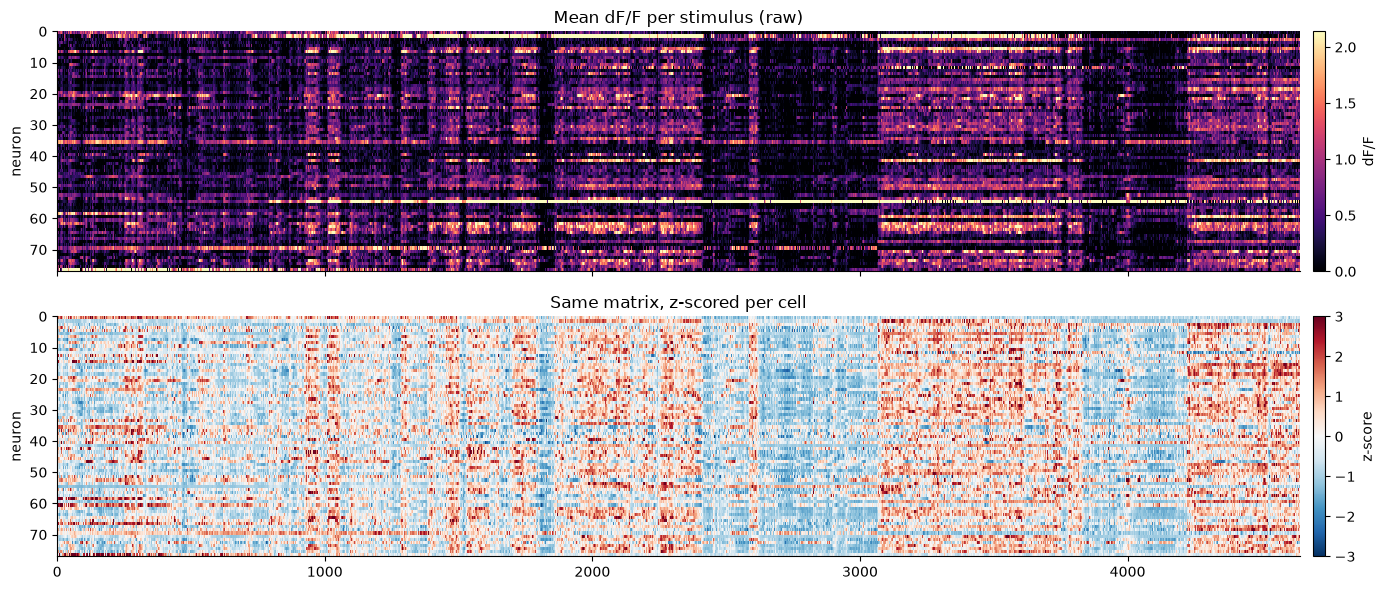

In [13]:
# Visualize the z-scored activity matrix.
from workshop2_utils import show_matrix

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
show_matrix(axes[0], fr_vl, 'magma', 0, np.nanpercentile(fr_vl, 98),
            'Mean dF/F per stimulus (raw)', 'dF/F')
show_matrix(axes[1], frz_vl, 'RdBu_r', -3, 3,
            'Same matrix, z-scored per cell', 'z-score')
plt.tight_layout()
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; max-width: 90%; overflow-x: auto; color: #000000;">

### Behavioral signal: running speed

Running speed is a slow behavioral signal that can co-fluctuate with neural activity on timescales of tens
of seconds.  We extract it from the `running` processing module and average
within each stimulus response window.

</div>

Running speed: mean=6.06, std=7.51 cm/s


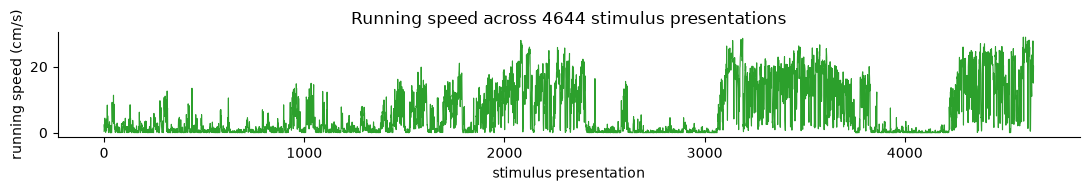

In [14]:
# Extract running speed and average within each stimulus window.
speed_series  = nwb.processing['running']['speed']
running_speed = np.asarray(speed_series.data[:])
running_ts    = np.asarray(speed_series.timestamps[:])

running_vl = np.array([
    np.mean(np.abs(running_speed[(running_ts >= row['start_time']) &
                                 (running_ts <  row['start_time'] + RESP_WIN)]))
    for _, row in stimuli.iterrows()
])

# Replace NaN (no running samples in window) with column mean
running_vl = np.where(np.isnan(running_vl), np.nanmean(running_vl), running_vl)

running_z_vl = (running_vl - running_vl.mean()) / (running_vl.std() + 1e-9)
print(f'Running speed: mean={running_vl.mean():.2f}, std={running_vl.std():.2f} cm/s')

fig, ax = plt.subplots(figsize=(11, 2))
ax.plot(running_vl, color='tab:green', lw=0.8)
ax.set_xlabel('stimulus presentation'); ax.set_ylabel('running speed (cm/s)')
ax.set_title(f'Running speed across {n_stimuli_vl} stimulus presentations')
plt.tight_layout(); plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; max-width: 90%; overflow-x: auto; color: #000000;">

### Plot the image changes

Color code each image identity, and create a map of each image transition across stimuli presentations.

</div>

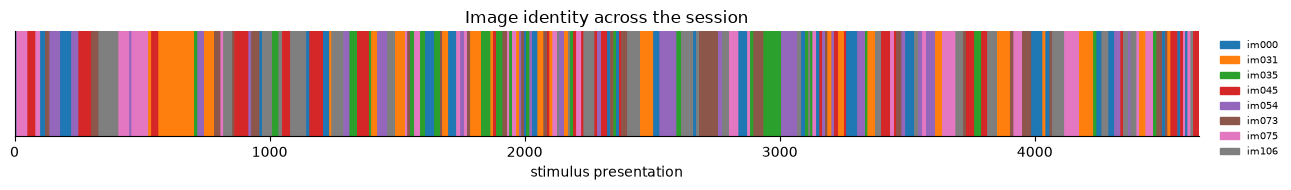

In [15]:
# Color-coded stimulus identity raster with shaded run backgrounds
unique_images = np.unique(stimuli['image_name'].values)
cmap = plt.cm.tab10
img_colors = {img: cmap(i % 10) for i, img in enumerate(unique_images)}

fig, ax = plt.subplots(figsize=(13, 2))

# Shade background for each run of the same image
run_start = 0
for i in range(1, len(stimuli) + 1):
    if i == len(stimuli) or stimuli['image_name'].iloc[i] != stimuli['image_name'].iloc[run_start]:
        img = stimuli['image_name'].iloc[run_start]
        ax.axvspan(run_start, i, color=img_colors[img], alpha=0.15, lw=0)
        run_start = i

# Draw one tick per stimulus, colored by image identity
for idx, row in stimuli.iterrows():
    ax.axvline(idx, color=img_colors[row['image_name']], lw=1.2, alpha=0.8)

# Legend
from matplotlib.patches import Patch
legend_handles = [Patch(color=img_colors[img], label=img) for img in unique_images]
ax.legend(handles=legend_handles, bbox_to_anchor=(1.01, 1), loc='upper left',
          fontsize=7, frameon=False)

ax.set_xlim(0, len(stimuli))
ax.set_yticks([])
ax.set_xlabel('stimulus presentation')
ax.set_title('Image identity across the session')
plt.tight_layout()
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; max-width: 90%; overflow-x: auto; color: #000000;">

### Plot neural activity, behavioral data, and image identity across all stimulus presentations

</div>

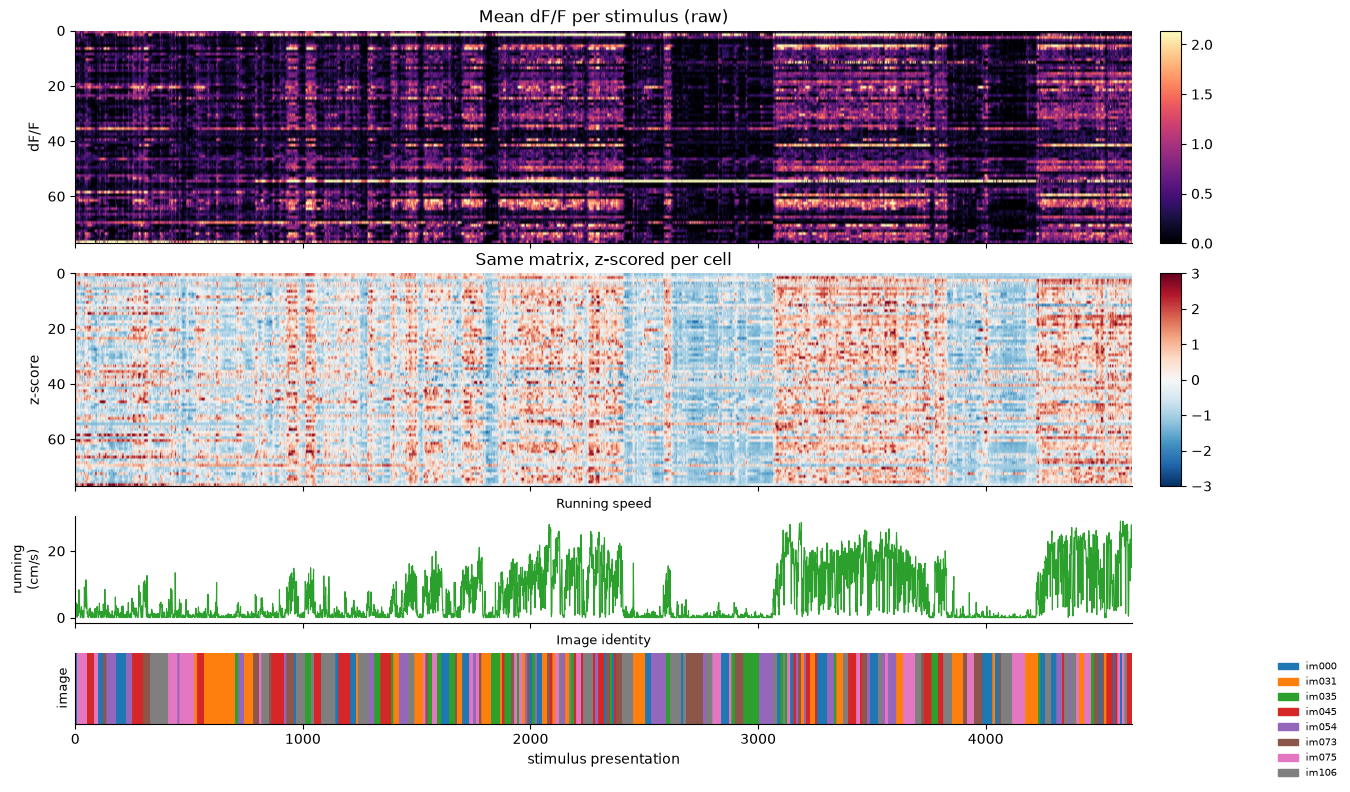

In [16]:
from matplotlib.patches import Patch

unique_images = np.unique(stimuli['image_name'].values)
cmap = plt.cm.tab10
img_colors = {img: cmap(i % 10) for i, img in enumerate(unique_images)}

fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True,
                         gridspec_kw={'height_ratios': [3, 3, 1.5, 1]})
fig.subplots_adjust(right=0.88)
cbar_x = 0.90
cbar_w = 0.015

# Panel 1: raw dF/F
im0 = axes[0].imshow(fr_vl, aspect='auto', cmap='magma',
                     vmin=0, vmax=np.nanpercentile(fr_vl, 98),
                     extent=[0, n_stimuli_vl, n_cells_vl, 0])
axes[0].set_title('Mean dF/F per stimulus (raw)')
axes[0].set_ylabel('dF/F')
h = axes[0].get_position().height
y = axes[0].get_position().y0
fig.colorbar(im0, cax=fig.add_axes([cbar_x, y, cbar_w, h]))

# Panel 2: z-scored
im1 = axes[1].imshow(frz_vl, aspect='auto', cmap='RdBu_r', vmin=-3, vmax=3,
                     extent=[0, n_stimuli_vl, n_cells_vl, 0])
axes[1].set_title('Same matrix, z-scored per cell')
axes[1].set_ylabel('z-score')
h = axes[1].get_position().height
y = axes[1].get_position().y0
fig.colorbar(im1, cax=fig.add_axes([cbar_x, y, cbar_w, h]))

# Panel 3: running speed
axes[2].plot(running_vl, color='tab:green', lw=0.8)
axes[2].set_ylabel('running\n(cm/s)', fontsize=9)
axes[2].set_title('Running speed', fontsize=9)

# Panel 4: image identity strip
ax = axes[3]
run_start = 0
for i in range(1, len(stimuli) + 1):
    if i == len(stimuli) or stimuli['image_name'].iloc[i] != stimuli['image_name'].iloc[run_start]:
        img = stimuli['image_name'].iloc[run_start]
        ax.axvspan(run_start, i, color=img_colors[img], alpha=0.15, lw=0)
        run_start = i

for idx, row in stimuli.iterrows():
    ax.axvline(idx, color=img_colors[row['image_name']], lw=1.2, alpha=0.8)

legend_handles = [Patch(color=img_colors[img], label=img) for img in unique_images]
ax.legend(handles=legend_handles, bbox_to_anchor=(1.13, 1), loc='upper left',
          fontsize=7, frameon=False)
ax.set_yticks([])
ax.set_ylabel('image', fontsize=9)
ax.set_xlabel('stimulus presentation')
ax.set_title('Image identity', fontsize=9)

plt.show()

<div style="border-left: 3px solid #f0b429; padding: 1px; padding-left: 10px; background: #FFF9C4; max-width: 90%; overflow-x: auto; color: #000000;">

### What can we hypothesize from this visualization?

<details>
<summary><b>Answer</b></summary>

It seems like many of these neurons might be correlated with running speed.

</details>

<br>



</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; max-width: 90%; overflow-x: auto; color: #000000;">

# Part 4: Test 1 — Correlation with Running Speed

Are VISp neurons correlated with running speed?  We apply the same
analysis as in Workshop 2:
1. **Parametric test** — Pearson r between each cell's dF/F and running speed.
2. **Circular shift null** — roll the neural matrix in the stimulus axis to
   break stimulus-by-stimulus alignment while preserving slow temporal structure.
   

</div>

n = 4644 stimuli  ->  |r| > 0.029 gives p < 0.05


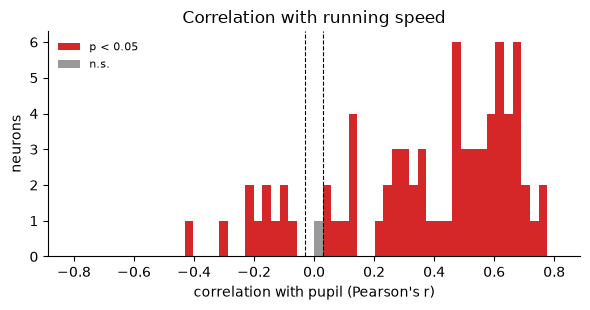

In [17]:
from workshop2_utils import corr_rows, crit_r, hist_by_significance

# Parametric correlations
r_vl      = corr_rows(fr_vl, running_vl)
r_crit_vl = crit_r(n_stimuli_vl)

res_vl   = [stats.pearsonr(fr_vl[i], running_vl) for i in range(n_cells_vl)]
p_vl     = np.array([x.pvalue for x in res_vl])
n_sig_vl = np.sum(p_vl < 0.05)

print(f'n = {n_stimuli_vl} stimuli  ->  |r| > {r_crit_vl:.3f} gives p < 0.05')

_edges = np.arange(0, 0.8 + r_crit_vl, r_crit_vl)
R_BINS_VL = np.concatenate([-_edges[1:][::-1], _edges])

fig, ax = plt.subplots(figsize=(6, 3.2))
hist_by_significance(ax, r_vl, 'Correlation with running speed', R_BINS_VL, r_crit_vl)
plt.tight_layout()
plt.show()

<div style="border-left: 3px solid #07bc0a; padding: 1px; padding-left: 10px; background: #DFF0D8;  max-width: 90%; overflow-x: auto; color: #000000;">

### Exercise: How many neurons appear correlated with running speed?

1. **How many neurons were found to be significantly correlated with running speed?** Print `n_sig_dr`. 

2. **How does this number compare to the `~5%` you'd expect by chance?**


</div>


In [18]:
# YOUR CODE HERE (uncomment this cell)
# 1. How many MOs neurons were significantly correlated with running speed:
print(f'{n_sig_vl} / {n_cells_vl} cells significant (p < 0.05)')


# 2. How does that number compare to the ~5% expected by chance:
n_chance = np.round((0.05 * n_cells_vl))
print(f'{n_chance:.0f} / {n_cells_vl} cells expected by chance')


76 / 77 cells significant (p < 0.05)
4 / 77 cells expected by chance


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; max-width: 90%; overflow-x: auto; color: #000000;">

### Interactively visualize the individual neuron traces aligned with running speed

Using the same interactive widget as Workshop 2, let's visualize the dF/F matrix sorted by correlation strength. Click on each neuron row to visualize its activity trace on top of the running trace.

</div>

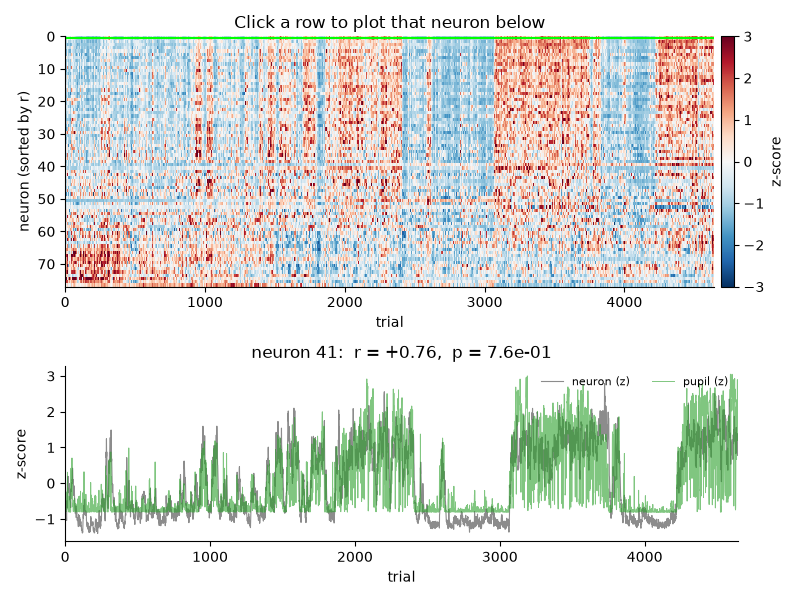

In [19]:
# Interactive figure: click any row in the matrix to plot that neuron's
# firing rate against the pupil trace below.
# Requires %matplotlib widget (ipympl) for the click callback to work.
%matplotlib widget

# sort neurons by correlation and display the activity matrix alongside the pupil
order_run = np.argsort(r_vl)[::-1]

# sort the z-scored firing rate matrix by correlation with pupil
M_sorted = frz_vl[order_run]

# setup the plotting area (2 subplots)
fig, (ax_im, ax_tr) = plt.subplots(2, 1, figsize=(8, 6),
                                   gridspec_kw=dict(height_ratios=[2, 1.4]))
fig.canvas.header_visible = False

# plot the sorted + z-scored firing rate matrix on the first subplot
show_matrix(ax_im, M_sorted, 'RdBu_r', -3, 3,
            'Click a row to plot that neuron below', 'z-score',
            ylabel='neuron (sorted by r)')
ax_im.set_xlabel('trial')
row_marker = ax_im.axhline(0.5, color='lime', lw=1.5)

# plot the pupil trace and the selected neuron's firing rate on the second subplot
line_neuron, = ax_tr.plot(M_sorted[0], color='0.55', lw=0.8, label='neuron (z)')
ax_tr.plot(running_z_vl, color='tab:green', lw=0.7, alpha=0.6, label='pupil (z)')
ax_tr.set_xlim(0, n_stimuli_vl)
ax_tr.set_xlabel('trial')
ax_tr.set_ylabel('z-score')
ax_tr.legend(frameon=False, fontsize=8, ncol=2, loc='upper right')

# in cell helper function that updates the second subplot when a new row is clicked in the first subplot
def show_row(row):
    i = order_run[row]
    line_neuron.set_ydata(frz_vl[i])
    row_marker.set_ydata([row + 0.5, row + 0.5])
    ax_tr.set_title(f'neuron {i}:  r = {r_vl[i]:+.2f},  p = {r_vl[i]:.1e}')
    ax_tr.relim()
    ax_tr.autoscale_view(scalex=False)
    fig.canvas.draw_idle()

# in cell helper function that handles mouse clicks on the first subplot
def on_click(event):
    if event.inaxes is ax_im and event.ydata is not None:
        show_row(int(np.clip(event.ydata, 0, n_cells_vl - 1)))

# connect the click event to the figure
fig.canvas.mpl_connect('button_press_event', on_click)
show_row(0)
plt.tight_layout()


In [20]:
# Run this cell to close the interactive figure and 
# switch back to inline plotting for the rest of the notebook.
plt.close('all')
%matplotlib inline


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; max-width: 90%; overflow-x: auto; color: #000000;">

### Apply the circular shift control

Let's apply the circular shift control to our neuronal signal to see what result we get. 

</div>

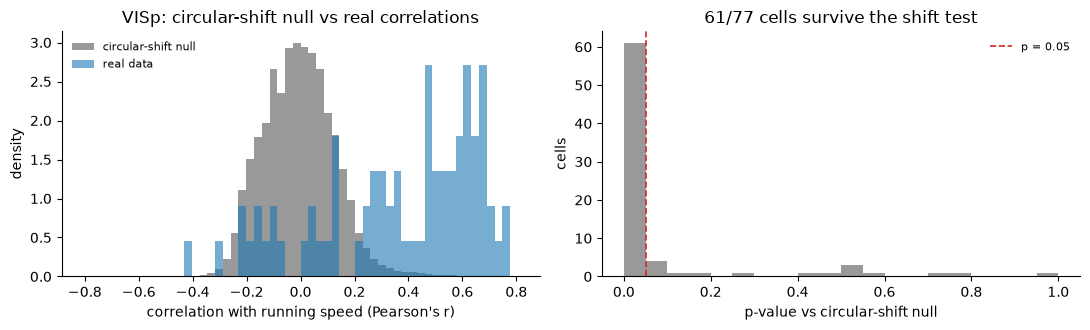

Parametric p < 0.05:           76 / 77
Circular-shift null p < 0.05:  61 / 77


In [21]:
# Circular shift null: roll neural matrix along stimulus axis.
N_SHIFT_VL = 200
shift_vl   = np.random.default_rng(42).integers(1, n_stimuli_vl, N_SHIFT_VL)

r_circ_vl     = np.array([corr_rows(np.roll(fr_vl, s, axis=1), running_vl)
                           for s in shift_vl])
p_circ_vl     = (np.sum(np.abs(r_circ_vl) >= np.abs(r_vl), axis=0) + 1) / (N_SHIFT_VL + 1)
n_sig_circ_vl = np.sum(p_circ_vl < 0.05)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].hist(r_circ_vl.ravel(), bins=R_BINS_VL, density=True, color='0.6',
             label='circular-shift null')
axes[0].hist(r_vl, bins=R_BINS_VL, density=True, color='tab:blue', alpha=0.6,
             label='real data')
axes[0].set_xlabel("correlation with running speed (Pearson's r)")
axes[0].set_ylabel('density')
axes[0].set_title('VISp: circular-shift null vs real correlations')
axes[0].legend(frameon=False, fontsize=8)

axes[1].hist(p_circ_vl, bins=np.linspace(0, 1, 21), color='0.6')
axes[1].axvline(0.05, color='tab:red', lw=1.2, ls='--', label='p = 0.05')
axes[1].set_xlabel('p-value vs circular-shift null')
axes[1].set_ylabel('cells')
axes[1].set_title(f'{n_sig_circ_vl}/{n_cells_vl} cells survive the shift test')
axes[1].legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

print(f'Parametric p < 0.05:          {n_sig_vl:3d} / {n_cells_vl}')
print(f'Circular-shift null p < 0.05: {n_sig_circ_vl:3d} / {n_cells_vl}')

In [22]:
sig_param_vl = p_vl < 0.05
sig_circ_vl  = p_circ_vl < 0.05
print(f'Both tests agree significant: {(sig_param_vl & sig_circ_vl).sum()}')
print(f'Parametric only:              {(sig_param_vl & ~sig_circ_vl).sum()}')
print(f'Circular shift only:          {(~sig_param_vl & sig_circ_vl).sum()}')
print(f'Both agree not significant:   {(~sig_param_vl & ~sig_circ_vl).sum()}')

Both tests agree significant: 61
Parametric only:              15
Circular shift only:          0
Both agree not significant:   1


<div style="border-left: 3px solid #07bc0a; padding: 1px; padding-left: 10px; background: #DFF0D8;  max-width: 90%; overflow-x: auto; color: #000000;">

### Exercise: Which neurons did not survive the circular shift?

1. **Plot the z-scored matrix of activity for neurons that were flagged in the parametric test but did not survive the circular shift.**


</div>


15 neurons: parametric significant, circular shift not significant


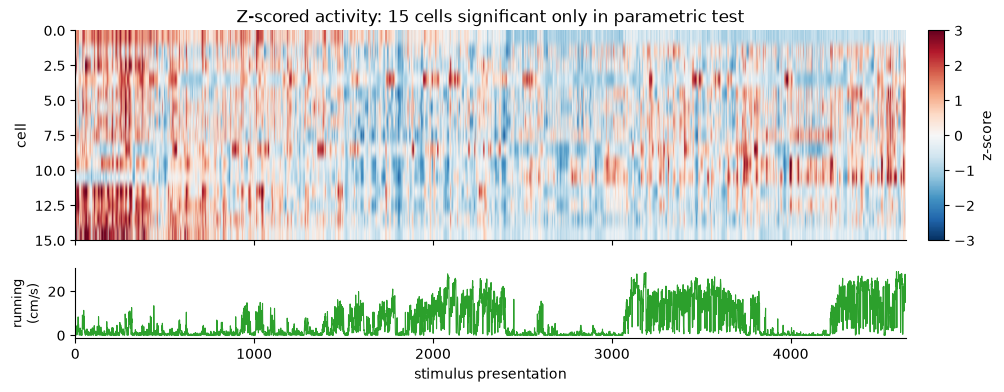

In [23]:
# YOUR CODE HERE
# Neurons significant in parametric test only (did not survive circular shift)
param_only = np.where(sig_param_vl & ~sig_circ_vl)[0]
print(f'{len(param_only)} neurons: parametric significant, circular shift not significant')

fig, axes = plt.subplots(2, 1, figsize=(11, 4), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})
fig.subplots_adjust(right=0.88)
cbar_x, cbar_w = 0.90, 0.015

im = axes[0].imshow(frz_vl[param_only], aspect='auto', cmap='RdBu_r', vmin=-3, vmax=3,
                    extent=[0, n_stimuli_vl, len(param_only), 0])
axes[0].set_ylabel('cell')
axes[0].set_title(f'Z-scored activity: {len(param_only)} cells significant only in parametric test')
h = axes[0].get_position().height
y = axes[0].get_position().y0
fig.colorbar(im, cax=fig.add_axes([cbar_x, y, cbar_w, h]), label='z-score')

axes[1].plot(running_vl, color='tab:green', lw=0.8)
axes[1].set_xlabel('stimulus presentation')
axes[1].set_ylabel('running\n(cm/s)', fontsize=9)

plt.show()

<div style="border-left: 3px solid #f0b429; padding: 1px; padding-left: 10px; background: #FFF9C4; max-width: 90%; overflow-x: auto; color: #000000;">

### What does this result indicate?

<details>
<summary><b>Answer</b></summary>

Many of the neurons that the parametric test flagged as correlated with running speed survived the circular shift, showing that we could find a true effect with this control!

Cells that survived only the parametric test have correlations that the
circular shift null cannot distinguish from chance. Whether they have genuine
running-speed coupling, or simply share a slow arousal-related drift, remains
unresolved without an even stronger temporal control.

</details>

<br>

</div>

---

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; max-width: 90%; overflow-x: auto; color: #000000;">

# Open-Ended Exercises

</div>

<div style="border-left: 3px solid #07bc0a; padding: 1px; padding-left: 10px; background: #DFF0D8; max-width: 90%; overflow-x: auto; color: #000000;">

### Open-Ended Exercise 1: Try the session-permutation null

The circular shift control preserves the session's own running speed but scrambles its trial-by-trial alignment with neural activity. Our earlier workshop looked at another control, the **session-permutation null**, which asks what if we pair this session's neurons with running speed from a completely different session?


Steps:

1. Identify all other sessions in `candidates` (excluding the current session).
2. For each other session, load its running speed and compute a per-stimulus average vector using that session's own stimulus timing.
3. Compute the Pearson correlation between each neuron's activity (in the current session) and the other session's running speed. Repeat for all available sessions to build a null distribution of shape (n_other_sessions, n_cells).
4. For each neuron, compute a session-permutation p-value: the fraction of permutation sessions where |r_null| >= |r_real|.
5. Plot the null vs real correlation distributions. Compare neuron counts surviving the parametric, circular-shift, and session-permutation tests.

</div>

11 other OPHYS_4_images_B sessions available as permutations
  loaded multiplane-ophys_782149_2025-04-29_09-15...  4615 stimuli
  loaded multiplane-ophys_788406_2025-07-15_10-39...  4600 stimuli
  loaded multiplane-ophys_788406_2025-07-16_12-07...  4610 stimuli
  loaded multiplane-ophys_790322_2025-07-07_12-19...  4611 stimuli
  loaded multiplane-ophys_790322_2025-07-08_12-35...  4616 stimuli
  loaded multiplane-ophys_800792_2025-08-18_14-43...  4620 stimuli
  loaded multiplane-ophys_800792_2025-08-19_13-08...  4599 stimuli
  loaded multiplane-ophys_800995_2025-08-25_10-49...  4612 stimuli
  loaded multiplane-ophys_800995_2025-08-26_10-28...  4633 stimuli
  loaded multiplane-ophys_804363_2025-08-29_14-47...  4604 stimuli
  loaded multiplane-ophys_804363_2025-09-02_11-50...  4600 stimuli

null correlation matrix: (11, 77)  (other sessions x cells)
11 sessions alone -> smallest possible p = 0.083; 0 cells reach p < 0.05
expanded null: 220 traces (11 sessions x 20 offsets)


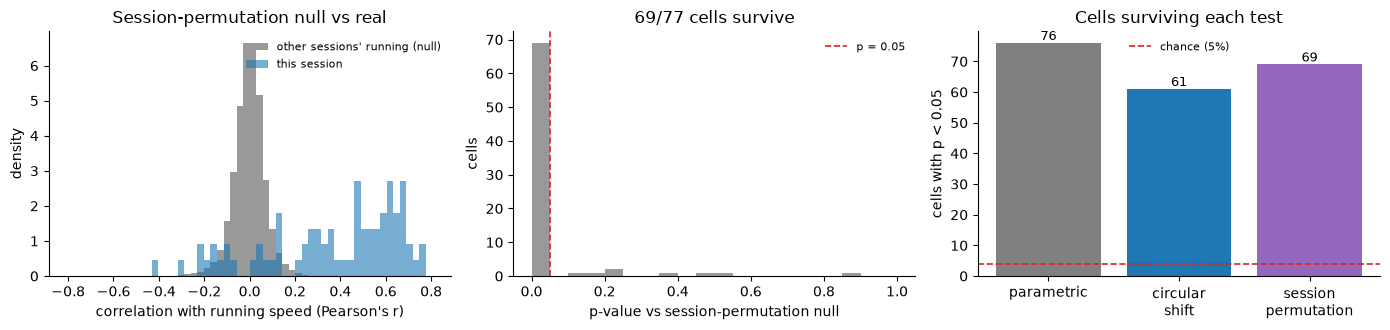


Parametric p < 0.05:             76 / 77
Circular-shift p < 0.05:         61 / 77
Session-permutation p < 0.05:    69 / 77

Both controls agree significant: 61
Circular shift only:            0
Session permutation only:       8
Neither control:                8


In [24]:
# YOUR CODE HERE
# ── Solution: Exercise 1 — Session-permutation null ───────────────────────
# Instead of shifting this session's running trace in time, we borrow the
# running trace from a *different* session. It has the same slow structure
# (same task, same timescale) but no relationship to these neurons.

# 1. All other sessions of this type
others = candidates[candidates['name'] != session['name']]
print(f'{len(others)} other {session["session_type"]} sessions available as permutations')


def running_per_stimulus(session_row, resp_win=RESP_WIN):
    """Load a session's running speed and average it in each of ITS OWN stimulus windows."""
    sdir = os.path.join(data_dir, 'Visual-Learning-SWDB', session_row['name'])
    fname = [p for p in os.listdir(sdir) if 'nwb' in p and not p.endswith('.json')][0]
    nwb_s = pynwb.read_nwb(os.path.join(sdir, fname))

    speed_s = nwb_s.processing['running']['speed']
    spd = np.asarray(speed_s.data[:])
    sts = np.asarray(speed_s.timestamps[:])

    stim_s = nwb_s.intervals['stimulus_presentations'].to_dataframe()
    stim_s = stim_s[stim_s['omitted'] != 1].reset_index(drop=True)

    v = np.array([np.mean(np.abs(spd[(sts >= t0) & (sts < t0 + resp_win)]))
                  for t0 in stim_s['start_time'].values])
    return np.where(np.isnan(v), np.nanmean(v), v)


# 2. Load each other session's running speed (~15-20 s per session)
run_other = {}
for _, row in others.iterrows():
    try:
        run_other[row['name']] = running_per_stimulus(row)
        print(f'  loaded {row["name"][:40]}...  {len(run_other[row["name"]])} stimuli')
    except Exception as e:
        print(f'  SKIPPED {row["name"][:40]}...  ({type(e).__name__}: {e})')

# Other sessions have slightly different numbers of stimuli, so wrap each trace
# to this session's length (np.resize tiles; it does not zero-pad).
null_run = {k: np.resize(v, n_stimuli_vl) for k, v in run_other.items()}

# 3. Correlate this session's neurons with each other session's running speed
r_sess = np.array([corr_rows(fr_vl, v) for v in null_run.values()])   # (n_other, n_cells)
print(f'\nnull correlation matrix: {r_sess.shape}  (other sessions x cells)')

# With only a handful of other sessions the smallest achievable p-value is
# 1/(n_other + 1) — too coarse to ever reach 0.05.
p_sess_raw = (np.sum(np.abs(r_sess) >= np.abs(r_vl), axis=0) + 1) / (len(null_run) + 1)
print(f'{len(null_run)} sessions alone -> smallest possible p = '
      f'{1/(len(null_run)+1):.3f}; {np.sum(p_sess_raw < 0.05)} cells reach p < 0.05')

# So expand the null: circularly offset each borrowed trace a few times. Each
# offset is still a real running trace from another animal/session, just
# realigned — this buys resolution without inventing structure.
N_OFFSET = 20
rng_sess = np.random.default_rng(7)
null_traces = np.array([np.roll(v, s)
                        for v in null_run.values()
                        for s in rng_sess.integers(0, n_stimuli_vl, N_OFFSET)])
r_null_vl = np.array([corr_rows(fr_vl, v) for v in null_traces])
print(f'expanded null: {len(null_traces)} traces '
      f'({len(null_run)} sessions x {N_OFFSET} offsets)')

# 4. Session-permutation p-value per neuron
p_sess_vl     = (np.sum(np.abs(r_null_vl) >= np.abs(r_vl), axis=0) + 1) / (len(null_traces) + 1)
sig_sess_vl   = p_sess_vl < 0.05
n_sig_sess_vl = sig_sess_vl.sum()

# 5. Plot null vs real, and compare the three tests
fig, axes = plt.subplots(1, 3, figsize=(14, 3.4))

axes[0].hist(r_null_vl.ravel(), bins=R_BINS_VL, density=True, color='0.6',
             label="other sessions' running (null)")
axes[0].hist(r_vl, bins=R_BINS_VL, density=True, color='tab:blue', alpha=0.6,
             label='this session')
axes[0].set_xlabel("correlation with running speed (Pearson's r)")
axes[0].set_ylabel('density')
axes[0].set_title('Session-permutation null vs real')
axes[0].legend(frameon=False, fontsize=8)

axes[1].hist(p_sess_vl, bins=np.linspace(0, 1, 21), color='0.6')
axes[1].axvline(0.05, color='tab:red', lw=1.2, ls='--', label='p = 0.05')
axes[1].set_xlabel('p-value vs session-permutation null')
axes[1].set_ylabel('cells')
axes[1].set_title(f'{n_sig_sess_vl}/{n_cells_vl} cells survive')
axes[1].legend(frameon=False, fontsize=8)

counts = [n_sig_vl, n_sig_circ_vl, n_sig_sess_vl]
axes[2].bar(['parametric', 'circular\nshift', 'session\npermutation'], counts,
            color=['0.5', 'tab:blue', 'tab:purple'])
axes[2].axhline(0.05 * n_cells_vl, color='tab:red', ls='--', lw=1.2, label='chance (5%)')
axes[2].set_ylabel('cells with p < 0.05')
axes[2].set_title('Cells surviving each test')
axes[2].legend(frameon=False, fontsize=8)
for i, c in enumerate(counts):
    axes[2].text(i, c, str(c), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print(f'\nParametric p < 0.05:            {n_sig_vl:3d} / {n_cells_vl}')
print(f'Circular-shift p < 0.05:        {n_sig_circ_vl:3d} / {n_cells_vl}')
print(f'Session-permutation p < 0.05:   {n_sig_sess_vl:3d} / {n_cells_vl}')
print(f'\nBoth controls agree significant: {(sig_circ_vl & sig_sess_vl).sum()}')
print(f'Circular shift only:            {(sig_circ_vl & ~sig_sess_vl).sum()}')
print(f'Session permutation only:       {(~sig_circ_vl & sig_sess_vl).sum()}')
print(f'Neither control:                {(~sig_circ_vl & ~sig_sess_vl).sum()}')


<div style="border-left: 3px solid #07bc0a; padding: 1px; padding-left: 10px; background: #DFF0D8; max-width: 90%; overflow-x: auto; color: #000000;">

### Open-Ended Exercise 2: Replace running speed with lick rate

1. Extract lick event times from `nwb.get_all_events()` (filter for `event_type == 'lick'`) or from the events table. Compute a lick rate per stimulus window (licks within the 0–0.5 s response window divided by window duration).

2. Run the same parametric + circular shift pipeline you used for running speed, substituting lick rate as the behavioral signal.

3. Compare the results:
   - Are more or fewer cells apparently correlated with lick rate than with running speed?
   - Does the same fraction survive the circular shift?
   - Do the *same individual cells* survive both tests for both signals, or are different cells implicated?

<details>
<summary><b>Hint</b></summary>

*Use `nwb.get_all_events()` to get a DataFrame of all behavioral events, then filter rows where `event_type == 'lick'` and extract the `timestamps` column. Count how many lick timestamps fall within each stimulus window using `np.sum((lick_ts >= t0) & (lick_ts < t1))` and divide by `RESP_WIN` to get a rate.*

</details>

<br>

</div>

2885 lick events in session
Lick rate: mean=0.77, std=1.82 licks/s


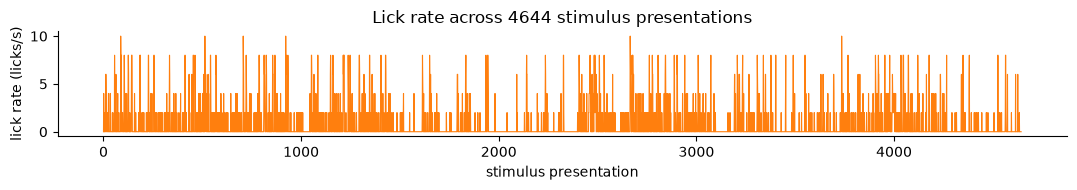

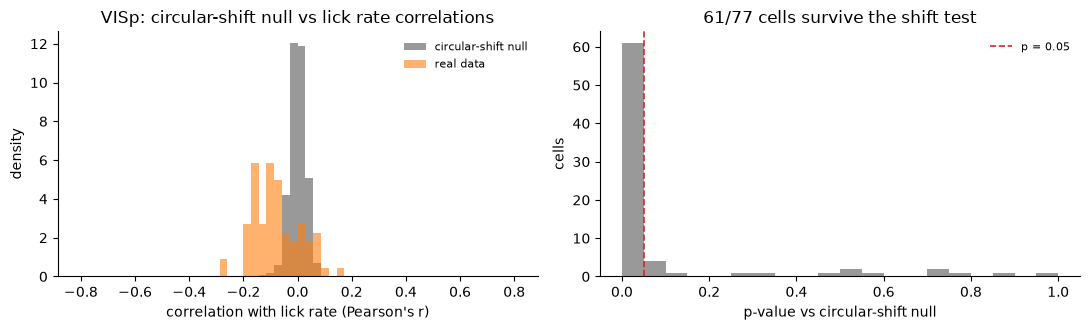

─────────────────────────────────────────────
Signal               param%    circ%
─────────────────────────────────────────────
Running speed           99%      79%
Lick rate               87%      79%

After circular shift:
  Both running and lick:  52
  Running only:           9
  Lick only:              9
  Neither:                7


In [25]:
# YOUR CODE HERE
# ── Solution: Exercise 2 — Lick rate instead of running speed ─────────────

# 1. Extract lick timestamps
behavior_events = nwb.get_all_events()
lick_ts = behavior_events[behavior_events['event_type'] == 'lick'].index.values
print(f'{len(lick_ts)} lick events in session')

# Compute lick rate per stimulus window
lick_rate_vl = np.array([
    np.sum((lick_ts >= row['start_time']) & (lick_ts < row['start_time'] + RESP_WIN)) / RESP_WIN
    for _, row in stimuli.iterrows()
])
print(f'Lick rate: mean={lick_rate_vl.mean():.2f}, std={lick_rate_vl.std():.2f} licks/s')

fig, ax = plt.subplots(figsize=(11, 2))
ax.plot(lick_rate_vl, color='tab:orange', lw=0.8)
ax.set_xlabel('stimulus presentation'); ax.set_ylabel('lick rate (licks/s)')
ax.set_title(f'Lick rate across {n_stimuli_vl} stimulus presentations')
plt.tight_layout(); plt.show()

# 2. Parametric correlations with lick rate
r_lick      = corr_rows(fr_vl, lick_rate_vl)
res_lick    = [stats.pearsonr(fr_vl[i], lick_rate_vl) for i in range(n_cells_vl)]
p_lick      = np.array([x.pvalue for x in res_lick])
n_sig_lick  = np.sum(p_lick < 0.05)

# Circular shift null
r_circ_lick     = np.array([corr_rows(np.roll(fr_vl, s, axis=1), lick_rate_vl)
                              for s in shift_vl])
p_circ_lick     = (np.sum(np.abs(r_circ_lick) >= np.abs(r_lick), axis=0) + 1) / (N_SHIFT_VL + 1)
n_sig_circ_lick = np.sum(p_circ_lick < 0.05)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].hist(r_circ_lick.ravel(), bins=R_BINS_VL, density=True, color='0.6',
             label='circular-shift null')
axes[0].hist(r_lick, bins=R_BINS_VL, density=True, color='tab:orange', alpha=0.6,
             label='real data')
axes[0].set_xlabel("correlation with lick rate (Pearson's r)")
axes[0].set_ylabel('density')
axes[0].set_title('VISp: circular-shift null vs lick rate correlations')
axes[0].legend(frameon=False, fontsize=8)

axes[1].hist(p_circ_lick, bins=np.linspace(0, 1, 21), color='0.6')
axes[1].axvline(0.05, color='tab:red', lw=1.2, ls='--', label='p = 0.05')
axes[1].set_xlabel('p-value vs circular-shift null')
axes[1].set_ylabel('cells')
axes[1].set_title(f'{n_sig_circ_lick}/{n_cells_vl} cells survive the shift test')
axes[1].legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

# 3. Compare running vs lick: which cells survive each test?
sig_param_lick = p_lick < 0.05
sig_circ_lick  = p_circ_lick < 0.05

print('─' * 45)
print(f'{"Signal":<18} {"param%":>8} {"circ%":>8}')
print('─' * 45)
print(f'{"Running speed":<18} {n_sig_vl/n_cells_vl*100:>7.0f}% {n_sig_circ_vl/n_cells_vl*100:>7.0f}%')
print(f'{"Lick rate":<18} {n_sig_lick/n_cells_vl*100:>7.0f}% {n_sig_circ_lick/n_cells_vl*100:>7.0f}%')
print()

# Overlap: cells surviving circular shift for BOTH signals
both_circ = (sig_circ_vl & sig_circ_lick).sum()
run_only  = (sig_circ_vl & ~sig_circ_lick).sum()
lick_only = (~sig_circ_vl & sig_circ_lick).sum()
neither   = (~sig_circ_vl & ~sig_circ_lick).sum()
print('After circular shift:')
print(f'  Both running and lick:  {both_circ}')
print(f'  Running only:           {run_only}')
print(f'  Lick only:              {lick_only}')
print(f'  Neither:                {neither}')

<div style="border-left: 3px solid #07bc0a; padding: 1px; padding-left: 10px; background: #DFF0D8; max-width: 90%; overflow-x: auto; color: #000000;">

### Open-Ended Exercise 3: Repeat the running speed analysis in a later novel session

The beginning of this notebook uses the first `OPHYS_4_images_B` session, where a mouse is **viewing novel images for the first time** after extensive training on a separate set of 'familiar' images. How correlated is neural activity with running speed or pupil speed on a later novel image session? How does it compare to activity during a late vs. early stage familiar session?

1. Repeat the analysis on a **late novel image session** (e.g. `OPHYS_4_images_B` session 12). Load it using the same pipeline.

2. Repeat the running speed (or pupil) correlation + circular shift analysis on the new session.

3. Compare the inflation factor (parametric % vs circular-shift %) across the two sessions:
   - Does the same degree of inflation appear in both?
   - Does the absolute number of correlated cells change, or just the inflation?
   - What might explain any differences between session types?

4. Repeat the full process on an **early** and **late** familiar session (e.g. `TRAINING_3_images_A_10uL_reward` session 0 vs `OPHYS_1_images_A` session 12).

<details>
<summary><b>Hint</b></summary>

*Use `candidates = metadata[metadata.session_type == 'OPHYS_4_images_B']` and `session = candidates.iloc[0]` to select a different session, then follow the same loading steps. You can wrap the full pipeline (load dF/F, compute activity matrix, correlate with running, apply circular shift) into a function that takes an NWB path and returns `n_sig_param, n_sig_circ, n_cells` so you can compare sessions in one cell.*

</details>

<br>

</div>

In [26]:
# Define helper functions
def load_session_data(session_row, plane='VISp_0', resp_win=0.5):
    """Load dF/F, apply QC, compute per-stimulus activity matrix and running speed."""
    import pynwb
    session_dir = os.path.join(data_dir, 'Visual-Learning-SWDB', session_row['name'])
    nwb_file = [p for p in os.listdir(session_dir)
                if 'nwb' in p and not p.endswith('.json')][0]
    nwb_s = pynwb.read_nwb(os.path.join(session_dir, nwb_file))

    # dF/F + timestamps
    dff_s = nwb_s.processing[plane]['dff_timeseries']['dff_timeseries']
    dff_arr = np.asarray(dff_s.data[:])
    ts_s = (np.asarray(dff_s.timestamps[:]) if dff_s.timestamps is not None
            else np.arange(dff_arr.shape[0]) / dff_s.rate + dff_s.starting_time)

    # QC
    roi = nwb_s.processing[plane]['image_segmentation'] \
               .plane_segmentations['roi_table'].to_dataframe()
    keep = np.flatnonzero(roi['is_soma'].values.astype(bool))
    dff_arr = dff_arr[:, keep]

    # Stimulus table
    stim_s = nwb_s.intervals['stimulus_presentations'].to_dataframe()
    stim_s = stim_s[stim_s['omitted'] != 1].copy().reset_index(drop=True)

    # Activity matrix
    n_cells_s = dff_arr.shape[1]
    fr_s = np.full((n_cells_s, len(stim_s)), np.nan)
    for ss, row in stim_s.iterrows():
        mask = (ts_s >= row['start_time']) & (ts_s < row['start_time'] + resp_win)
        if mask.sum() > 0:
            fr_s[:, ss] = dff_arr[mask].mean(axis=0)
    has_data = ~np.isnan(fr_s).any(axis=0)
    fr_s   = fr_s[:, has_data]
    stim_s = stim_s[has_data].reset_index(drop=True)

    # Running speed
    spd    = nwb_s.processing['running']['speed']
    run_spd = np.asarray(spd.data[:])
    run_ts  = np.asarray(spd.timestamps[:])
    run_s = np.array([
        np.mean(np.abs(run_spd[(run_ts >= row['start_time']) &
                                (run_ts <  row['start_time'] + resp_win)]))
        for _, row in stim_s.iterrows()
    ])
    run_s = np.where(np.isnan(run_s), np.nanmean(run_s), run_s)

    return fr_s, run_s, stim_s


def run_correlation_and_plot(fr_s, run_s, label, n_shift=200):
    """Run parametric + circular shift correlation and plot results."""
    n_cells_s, n_stimuli_s = fr_s.shape
    r_crit_s = crit_r(n_stimuli_s)

    _edges = np.arange(0, 0.8 + r_crit_s, r_crit_s)
    r_bins = np.concatenate([-_edges[1:][::-1], _edges])

    # Parametric
    r_s   = corr_rows(fr_s, run_s)
    p_s   = np.array([stats.pearsonr(fr_s[i], run_s).pvalue for i in range(n_cells_s)])
    n_sig = int(np.sum(p_s < 0.05))

    # Circular shift
    shifts = np.random.default_rng(42).integers(1, n_stimuli_s, n_shift)
    r_null = np.array([corr_rows(np.roll(fr_s, sh, axis=1), run_s) for sh in shifts])
    p_circ = (np.sum(np.abs(r_null) >= np.abs(r_s), axis=0) + 1) / (n_shift + 1)
    n_sig_circ = int(np.sum(p_circ < 0.05))

    print(f'{label}')
    print(f'  {n_cells_s} cells | parametric: {n_sig}/{n_cells_s} ({n_sig/n_cells_s*100:.0f}%) '
          f'| circular shift: {n_sig_circ}/{n_cells_s} ({n_sig_circ/n_cells_s*100:.0f}%)')

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
    axes[0].hist(r_null.ravel(), bins=r_bins, density=True, color='0.6',
                 label='circular-shift null')
    axes[0].hist(r_s, bins=r_bins, density=True, color='tab:blue', alpha=0.6,
                 label='real data')
    axes[0].set_xlabel("correlation with running speed (Pearson's r)")
    axes[0].set_ylabel('density')
    axes[0].set_title(f'{label}: null vs real correlations')
    axes[0].legend(frameon=False, fontsize=8)

    axes[1].hist(p_circ, bins=np.linspace(0, 1, 21), color='0.6')
    axes[1].axvline(0.05, color='tab:red', lw=1.2, ls='--', label='p = 0.05')
    axes[1].set_xlabel('p-value vs circular-shift null')
    axes[1].set_ylabel('cells')
    axes[1].set_title(f'{n_sig_circ}/{n_cells_s} cells survive the shift test')
    axes[1].legend(frameon=False, fontsize=8)
    plt.tight_layout()
    plt.show()

    return dict(n_cells=n_cells_s, n_sig_param=n_sig, n_sig_circ=n_sig_circ)

Novel — early session
  77 cells | parametric: 76/77 (99%) | circular shift: 61/77 (79%)


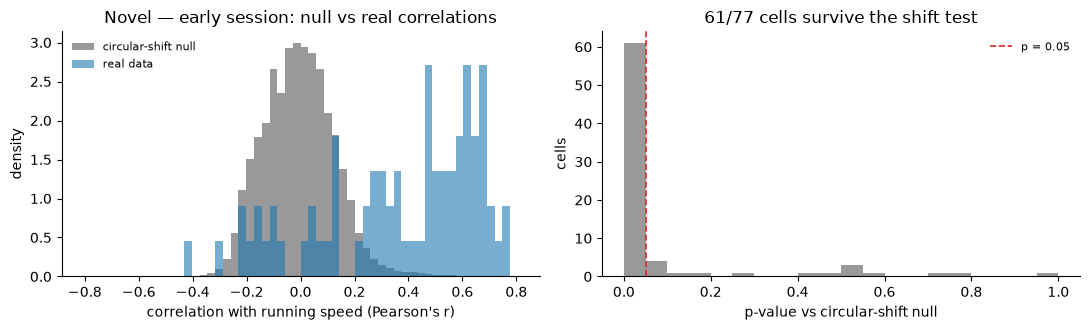

In [27]:
novel_early = metadata[metadata.session_type == 'OPHYS_4_images_B'].iloc[0]
fr_s, run_s, stim_s = load_session_data(novel_early)
results_novel_early = run_correlation_and_plot(fr_s, run_s, 'Novel — early session')

Novel — late session
  75 cells | parametric: 65/75 (87%) | circular shift: 52/75 (69%)


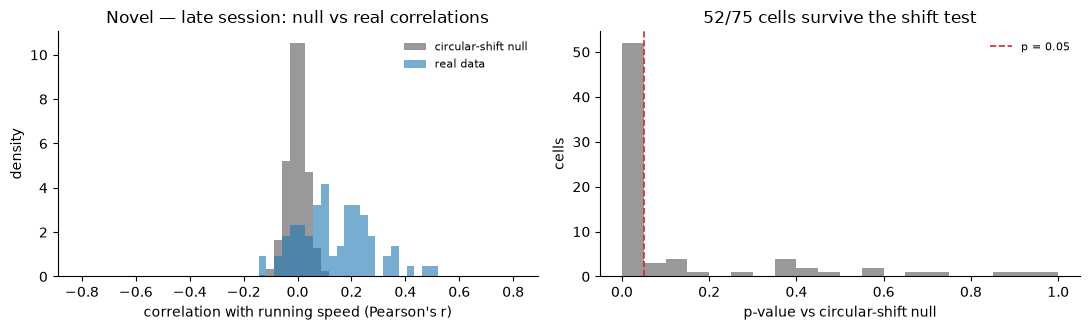

In [28]:
novel_late = metadata[metadata.session_type == 'OPHYS_4_images_B'].iloc[-1]
fr_s, run_s, stim_s = load_session_data(novel_late)
results_novel_late = run_correlation_and_plot(fr_s, run_s, 'Novel — late session')

Familiar — early session
  83 cells | parametric: 81/83 (98%) | circular shift: 72/83 (87%)


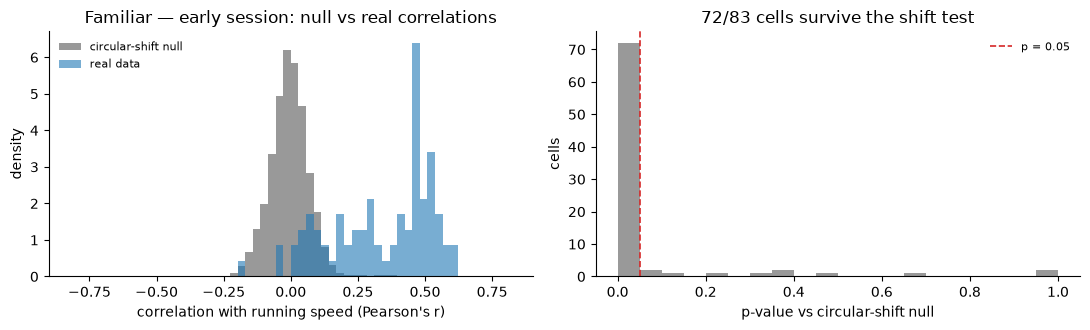

In [29]:
familiar_early = metadata[metadata.session_type == 'TRAINING_3_images_A_10uL_reward'].iloc[0]
fr_s, run_s, stim_s = load_session_data(familiar_early)
results_familiar_early = run_correlation_and_plot(fr_s, run_s, 'Familiar — early session')

Familiar — late session
  71 cells | parametric: 68/71 (96%) | circular shift: 61/71 (86%)


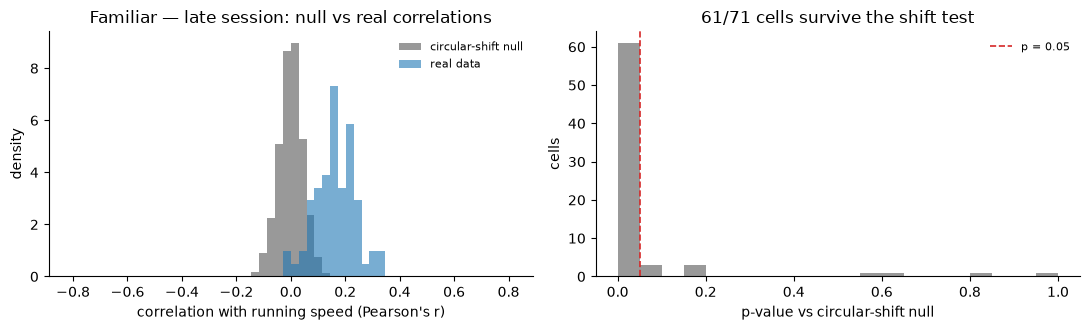

In [30]:
familiar_late = metadata[metadata.session_type == 'OPHYS_1_images_A'].iloc[-1]
fr_s, run_s, stim_s = load_session_data(familiar_late)
results_familiar_late = run_correlation_and_plot(fr_s, run_s, 'Familiar — late session')

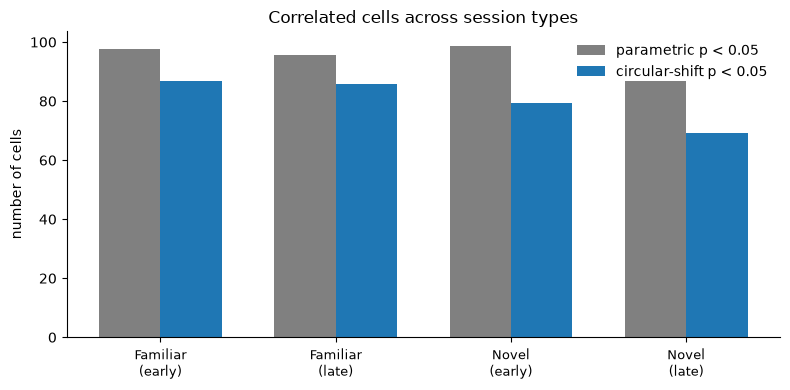

In [31]:
# Summary comparison
all_results = {
    'Familiar\n(early)': results_familiar_early,
    'Familiar\n(late)':  results_familiar_late,
    'Novel\n(early)':    results_novel_early,
    'Novel\n(late)':     results_novel_late,
}

labels     = list(all_results.keys())
pct_param = [all_results[l]['n_sig_param'] / all_results[l]['n_cells'] * 100 for l in labels]
pct_circ  = [all_results[l]['n_sig_circ']  / all_results[l]['n_cells'] * 100 for l in labels]

x, w = np.arange(len(labels)), 0.35

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - w/2, pct_param, w, color='0.5',      label='parametric p < 0.05')
ax.bar(x + w/2, pct_circ,  w, color='tab:blue', label='circular-shift p < 0.05')
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('number of cells')
ax.set_title('Correlated cells across session types')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()